####Data Exploration

In [63]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [ ]:
import pandas as pd
df = pd.read_csv('/insurance.csv')
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [ ]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [ ]:
df.tail()

,age,sex,bmi,children,smoker,region,charges
1333,50,male,30.97,3,no,northwest,10600.5483
1334,18,female,31.92,0,no,northeast,2205.9808
1335,18,female,36.85,0,no,southeast,1629.8335
1336,21,female,25.80,0,no,southwest,2007.9450
1337,61,female,29.07,0,yes,northwest,29141.3603


In [ ]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


####Data Cleaning

In [ ]:
df.isnull().sum()


,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.drop_duplicates(inplace=True)

####EDA

<>:9: SyntaxWarning: invalid escape sequence '\m'
<>:9: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipython-input-1421243443.py:9: SyntaxWarning: invalid escape sequence '\m'
  plt.legend(['Normal dist. ($\mu=$ {:.2f} and $\sigma=$ {:.2f} )'.format(mu, sigma)], loc='best')
/tmp/ipython-input-1421243443.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['charges'], fit=stats.norm)


Text(0, 0.5, 'Frequency')

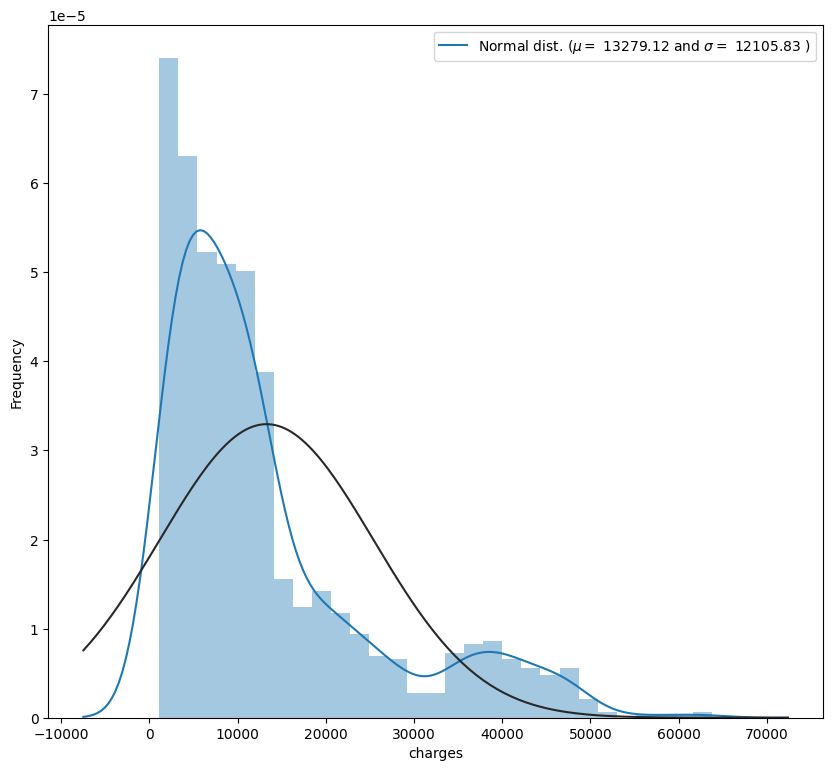

In [ ]:
from scipy import stats

plt.subplots(figsize=(10,9))
sns.distplot(df['charges'], fit=stats.norm)

(mu, sigma) = stats.norm.fit(df['charges'])

# plot with the distribution
plt.legend(['Normal dist. ($\mu=$ {:.2f} and $\sigma=$ {:.2f} )'.format(mu, sigma)], loc='best')
plt.ylabel('Frequency')

<>:7: SyntaxWarning: invalid escape sequence '\m'
<>:7: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipython-input-3721308780.py:7: SyntaxWarning: invalid escape sequence '\m'
  plt.legend(['Normal dist. ($\mu=$ {:.2f} and $\sigma=$ {:.2f} )'.format(mu, sigma)], loc='best')
/tmp/ipython-input-3721308780.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['charges'], fit=stats.norm)


Text(0, 0.5, 'Frequency')

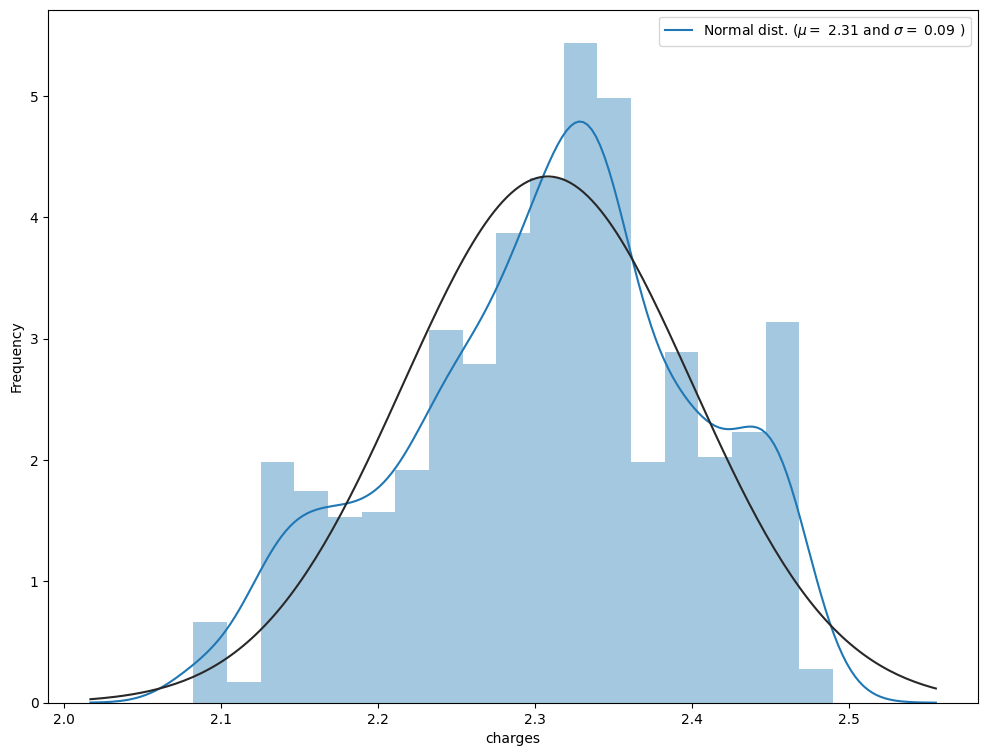

In [ ]:
df['charges'] = np.log1p(df['charges'])

plt.subplots(figsize=(12,9))
sns.distplot(df['charges'], fit=stats.norm)
(mu, sigma) = stats.norm.fit(df['charges'])

plt.legend(['Normal dist. ($\mu=$ {:.2f} and $\sigma=$ {:.2f} )'.format(mu, sigma)], loc='best')
plt.ylabel('Frequency')

In [ ]:
df['charges']

,charges
0,2.373438
1,2.134626
2,2.240791
3,2.397726
4,2.225753
...,...
1333,2.329106
1334,2.163252
1335,2.127856
1336,2.152386


In [ ]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

In [101]:
col = ['sex', 'smoker', 'region']

le = LabelEncoder()

for i in col:
  df[i] = le.fit_transform(df[i])

In [36]:
df.corr

<bound method DataFrame.corr of       age  sex     bmi  children  smoker  region   charges
0      19    0  27.900         0       1       3  2.373438
1      18    1  33.770         1       0       2  2.134626
2      28    1  33.000         3       0       2  2.240791
3      33    1  22.705         0       0       1  2.397726
4      32    1  28.880         0       0       1  2.225753
...   ...  ...     ...       ...     ...     ...       ...
1333   50    1  30.970         3       0       1  2.329106
1334   18    0  31.920         0       0       0  2.163252
1335   18    0  36.850         0       0       2  2.127856
1336   21    0  25.800         0       0       3  2.152386
1337   61    0  29.070         0       1       1  2.423027

[1337 rows x 7 columns]>

<Axes: >

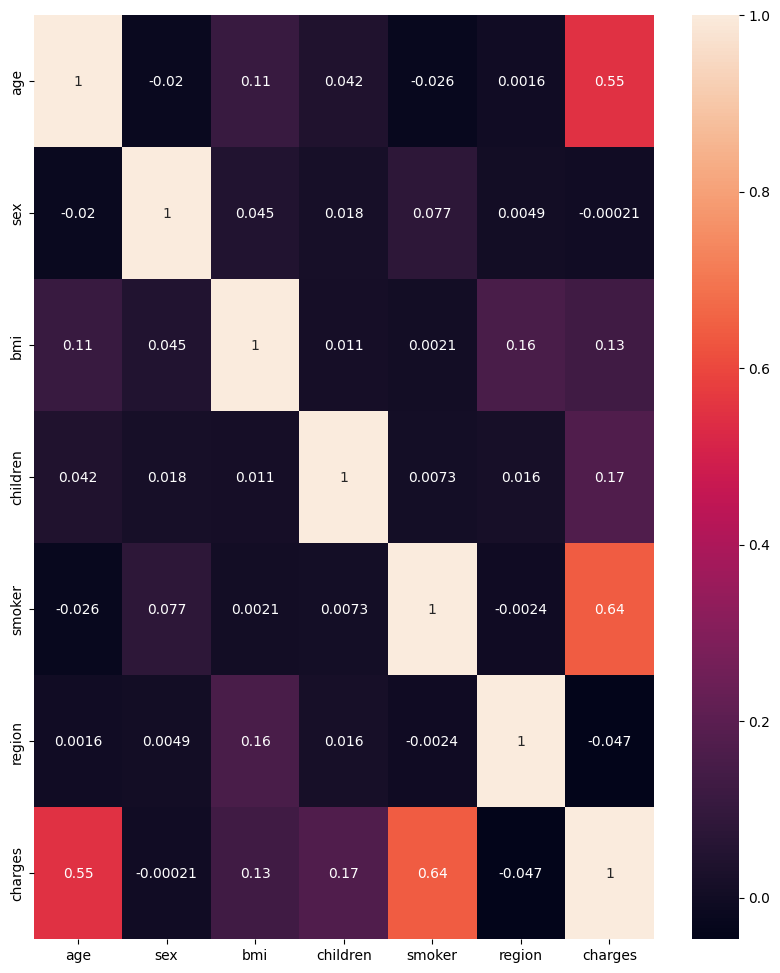

In [102]:
corr = df.corr()
plt.subplots(figsize=(10,12))
sns.heatmap(corr, annot=True)

####Prepare Modeling

In [112]:
Y = df['charges']
X = df.drop('charges' , axis=1).values
Y=Y.values


In [113]:
X_train,X_test,Y_train,Y_test = train_test_split(X ,Y , test_size = 0.80)

In [114]:
X_test

array([[ 34,   0, 272,   1,   0,   0],
       [  8,   0,  67,   0,   0,   1],
       [ 32,   1, 300,   0,   1,   0],
       ...,
       [ 34,   1, 310,   3,   0,   0],
       [ 28,   0, 260,   2,   0,   3],
       [ 40,   0, 314,   1,   0,   0]])

####Linear Regression

In [116]:

from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, Y_train)
print("Accuracy --> ", model.score(X_test, Y_test)*100)


print("Predict value " + str(model.predict([X_test[50]])))
print("Real value " + str(Y_test[50]))

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

y_pred = model.predict(X_test)

mae = mean_absolute_error(Y_test, y_pred)
mse = mean_squared_error(Y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(Y_test, y_pred)

print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("Root Mean Squared :" ,rmse)
print("R-squared:", r2)


Accuracy -->  74.78260313706329
Predict value [2.32584589]
Real value 2.4020024688721366
Mean Absolute Error: 0.029603154070508682
Mean Squared Error: 0.0021217822390054816
Root Mean Squared : 0.0460628075458442
R-squared: 0.7478260313706329


####Support Vector Regresser

In [118]:
from sklearn.svm import SVR
svr = SVR(kernel='rbf')
svr.fit(X_train, Y_train)


#Prediction
print("Predict value " + str(svr.predict([X_test[0]])))
print("Real value " + str(Y_test[0]))
print("Accuracy --> ", svr.score(X_test, Y_test)*100)

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

y_pred = svr.predict(X_test)

mae = mean_absolute_error(Y_test, y_pred)
mse = mean_squared_error(Y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(Y_test, y_pred)

print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("Root Mean Squared :" ,rmse)
print("R-squared:", r2)

Predict value [2.39377544]
Real value 2.3308952855311946
Accuracy -->  19.735361507635606
Mean Absolute Error: 0.07228791807830694
Mean Squared Error: 0.006753436339957794
Root Mean Squared : 0.08217929386383041
R-squared: 0.19735361507635607


####Decision Tree Regressor

In [122]:
from sklearn.tree import DecisionTreeRegressor
dtr = DecisionTreeRegressor()
dtr.fit(X_train, Y_train)


#Prediction
print("Predict value " + str(dtr.predict([X_test[20]])))
print("Real value " + str(Y_test[20]))
print("Accuracy --> ", dtr.score(X_test, Y_test)*100)

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

y_pred = dtr.predict(X_test)

mae = mean_absolute_error(Y_test, y_pred)
mse = mean_squared_error(Y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(Y_test, y_pred)

print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("Root Mean Squared :" ,rmse)
print("R-squared:", r2)


Predict value [2.46391238]
Real value 2.459407299655104
Accuracy -->  56.76085108120152
Mean Absolute Error: 0.0316773579884524
Mean Squared Error: 0.0036381256441445223
Root Mean Squared : 0.06031687694289652
R-squared: 0.5676085108120152


####Gradient Boosting Regressor

In [125]:
#Train the model
from sklearn.ensemble import GradientBoostingRegressor
GBR = GradientBoostingRegressor(n_estimators=4, max_depth=4)
#Fit
GBR.fit(X_train, Y_train)
#Prediction
print("Predict value " + str(model.predict([X_test[20]])))
print("Real value " + str(Y_test[20]))
print("Accuracy --> ", GBR.score(X_test, Y_test)*100)

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

y_pred = GBR.predict(X_test)

mae = mean_absolute_error(Y_test, y_pred)
mse = mean_squared_error(Y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(Y_test, y_pred)

print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("Root Mean Squared :" ,rmse)
print("R-squared:", r2)

Predict value [2.49508401]
Real value 2.459407299655104
Accuracy -->  46.50214559768583
Mean Absolute Error: 0.05414842937984078
Mean Squared Error: 0.004501289245384562
Root Mean Squared : 0.06709164810454847
R-squared: 0.4650214559768583


####Random Forest Regressor

In [126]:
#Train the model
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor(n_estimators=4)
#Fit
model.fit(X_train, Y_train)

#Prediction
print("Predict value " + str(model.predict([X_test[142]])))
print("Real value " + str(Y_test[142]))

#Score/Accuracy
print("Accuracy --> ", model.score(X_test, Y_test)*100)
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

y_pred = model.predict(X_test)

mae = mean_absolute_error(Y_test, y_pred)
mse = mean_squared_error(Y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(Y_test, y_pred)

print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("Root Mean Squared :" ,rmse)
print("R-squared:", r2)


Predict value [2.25825781]
Real value 2.2229214331022717
Accuracy -->  74.51194062865561
Mean Absolute Error: 0.024700259806385252
Mean Squared Error: 0.0021445556801431807
Root Mean Squared : 0.04630934765404476
R-squared: 0.745119406286556


####Summary



1338 rows and 7 columns age	bmi	children	charges
count	1338.000000	1338.000000	1338.000000	1338.000000
mean	39.207025	30.663397	1.094918	13270.422265
std	14.049960	6.098187	1.205493	12110.011237
min	18.000000	15.960000	0.000000	1121.873900
25%	27.000000	26.296250	0.000000	4740.287150
50%	39.000000	30.400000	1.000000	9382.033000
75%	51.000000	34.693750	2.000000	16639.912515
max	64.000000	53.130000	5.000000	63770.428010

 Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object
 5   region    1338 non-null   object
 6   charges   1338 non-null   float64

model
linear regression ki acuuracy tabhi achi ayi hai kukay features aur target ke beech linear relation strong hai or rmse or mse ki tabhiachi ayi hai  kukay model ke predictions real values ke bohot kareeb hain
